# Basics of Scipy

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## 1. Optimization

- [Scipy Docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)

In [33]:
from scipy.optimize import minimize

# help
# minimize?

**Example 1: Involving simple expression.**

Minimize $f(x)=(x-3)^2$

- Create a function `f(x)` as a python function.
- Requires an initial guess, `x0`

In [34]:
def f(x):
    return (x-3)**2

res = minimize(f, x0=1)

In [35]:
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 3.2397920662551844e-16
        x: [ 3.000e+00]
      nit: 2
      jac: [-2.110e-08]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3

In [36]:
print(f"Solution of optimization = {res.x} \n")

print(f"Optimizer exited successfully = {res.success} \n")

print(f"Value of objective function at optimal = {res.fun} \n")

print(f"Numerical error at solution: = {res.jac} \n")

Solution of optimization = [2.99999998] 

Optimizer exited successfully = True 

Value of objective function at optimal = 3.2397920662551844e-16 

Numerical error at solution: = [-2.10976836e-08] 



**Example 2: Involving Multidimensional, multiple constraints with bounds** 

Minimize $f(x,y) = (x-1)^2 + (y - 2.5) ^ 2$ subject to following constraint:

$$
x - 2y + 2 \ge 0
$$

$$
- x - 2y + 6 \ge 0
$$

$$
- x + 2y + 2 \ge 0
$$


Bound to: 
$$
x \ge 0
$$

$$
y \ge 0
$$

**Define a function:**

Here, function ``f`` that takes a vector input

In [37]:
def f(vect):
    """Here, vect is a 2d vector: [x, y]"""
    x = vect[0]
    y = vect[1]
    return (x - 1)**2 + (y - 2.5)**2

**Define a Constraints:**
- **Equality** `eq`: Function must be written so it equals exactly zero. **($f(x) = 0$)**
- **Inequality** `ineq`: Your function must be written so it is greater than or equal to zero. **($f(x) \ge 0$)**

In [38]:
def constraint_1(vect):
    """
    Constraint 1: x-2y+2
    """
    x = vect[0]
    y = vect[1]
    return x - 2 * y + 2


def constraint_2(vect):
    """
    Constraint 1: -x-2y+6
    """
    x = vect[0]
    y = vect[1]
    return - x - 2 * y + 6

def constraint_3(vect):
    """
    Constraint 1: x-2y+2
    """
    x = vect[0]
    y = vect[1]
    return - x + 2 * y + 2

constraints = (
    {
        'type': 'ineq',
        'fun': constraint_1 # x-2y+2
    },
    {
        'type': 'ineq', 
        'fun': constraint_2 # -x-2y+6
    },
    {
        'type': 'ineq', 
        'fun': constraint_3 # -x+2y+2
    }
)

**Define bounds for x and y**

Sequence of `(min, max)` pairs for each element in x. None is used to specify no bound.

In [39]:
bounds = (
    (0, None), # x >= 0
    (0, None)  # y >= 0
)

**Initial guess:** Initial guess of: `(2, 0)`
- Test out with multipler available solvers if needed.

In [40]:
res = minimize(
    f, 
    x0=(2, 0),
    bounds=bounds,
    constraints=constraints
    # method= solver
)

print(f"Optimal value:\nx = {res.x[0]}, y = {res.x[1]}")

res

Optimal value:
x = 1.400000003383427, y = 1.7000000009466523


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.800000001192098
           x: [ 1.400e+00  1.700e+00]
         nit: 3
         jac: [ 8.000e-01 -1.600e+00]
        nfev: 10
        njev: 3
 multipliers: [ 8.000e-01  0.000e+00  0.000e+00]

## 2. Interpolation:

Interpolation in numerical methods is a mathematical technique used to **estimate unknown values** that lie **between a set of known data points**.

Suppose, We have a 10 readings of an experiment.

In [41]:
from scipy.interpolate import interp1d

In [42]:
x = np.linspace(0, 10, 10)

y = x ** 2 * np.sin(x)

Lets visualize our experimental datasets.

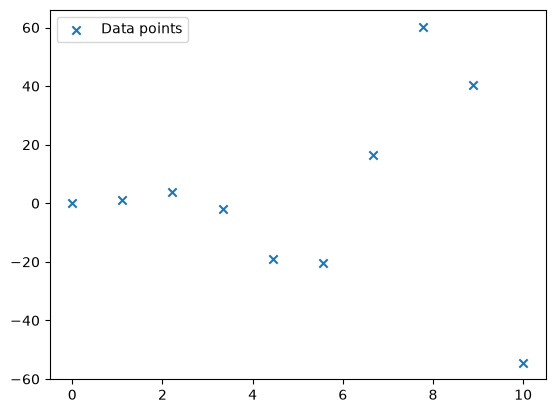

In [43]:
plt.scatter(x, y, marker='x', label="Data points")
plt.legend()

plt.show()

**1d interpolation**

Usage: `interp1d(x, y, kind="<linear/cubic>")` this **returns a function** that takes a value.

- For example we are using `linear` interpolator. Experiment or adjust as needed.

In [44]:
# help
# interp1d? 
f_linear = interp1d(x, y, kind='linear')

Output value at `x` is given by:

In [45]:
test_val = 8
print(f"Value at {test_val} is = {f_linear(test_val)}")

Value at 8 is = 56.32344445613671


Let's analyze graphically.

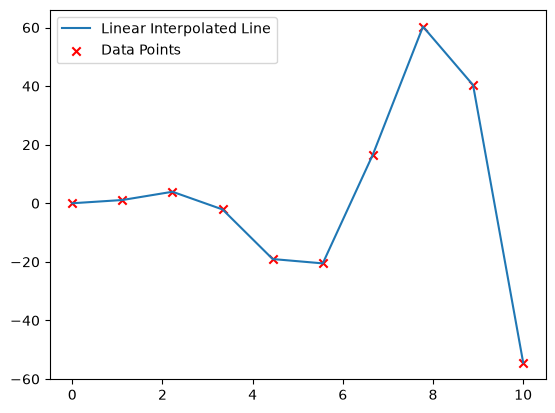

In [46]:
plt.plot(x, f_linear(x), label='Linear Interpolated Line')

plt.scatter(x, y, marker='x', color='r', label='Data Points')

plt.legend()

plt.show()

**Let's compare different kinds of interpolator.**
- For this we'll test the interpolated function with 100 data points (`x_dense`) in the input range of x from our experiment.
- And then plot the graph thus obtain

In [47]:
x_dense = np.linspace(min(x), max(x), 100)

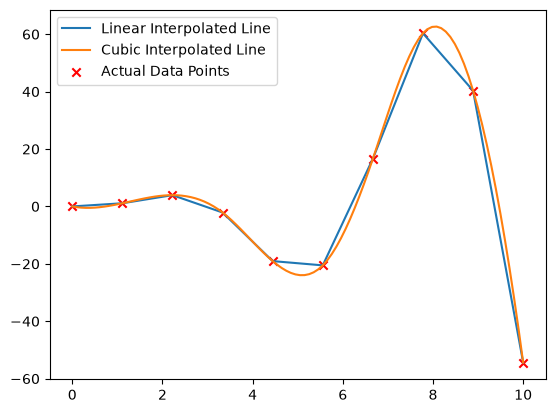

In [48]:
f_cubic = interp1d(x, y, kind='cubic')



plt.plot(x_dense, f_linear(x_dense), label='Linear Interpolated Line')
plt.plot(x_dense, f_cubic(x_dense), label='Cubic Interpolated Line')



plt.scatter(x, y, marker='x', color='r', label='Actual Data Points')

plt.legend()

plt.show()

## 3. Curve Fitting

In [49]:
from scipy.optimize import curve_fit

# curve_fit?

Curve fitting in numerical methods is the process of building a mathematical function or curve that best matches a set of data points.

**Intutive Example**

Suppose, we have a data points x and y and we assume the best fit equation relating to our data point would be, **ax+by**. Our main goal here would be to figure out the values of **a and b**

**Example 1:**

- We'll generate a few test data points.
- Try to fit it to linear fitter with equation $ax^2 + b$
- We'll try to figure out values of **a and b**

**Test Datas**

In [52]:
x = np.linspace(0, 10, 10)
y = 3 * x ** 2 + 2

**Let's plot the data:**

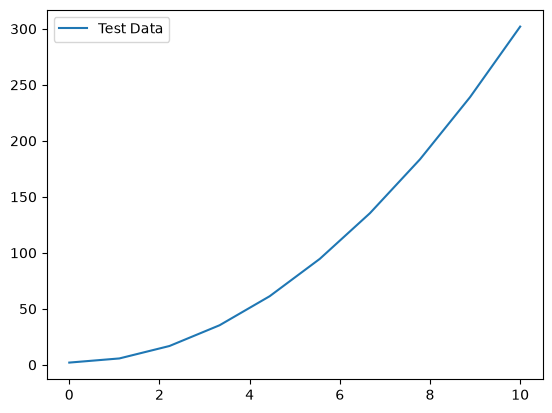

In [66]:
plt.plot(x, y, label="Test Data")

plt.legend()
plt.show()


**Define a function to which the data is to be fitted:**

- Note the order of parameters for this function is  ``(x, a, b)`` i.e. 
- Note that, a and b are additional parameters that comes after x.

```python
# standard example
def my_function(x, a, b, c):
    # 'x' is your input data (usually a numpy array)
    # 'a', 'b', 'c' are the parameters curve_fit will estimate
    return a * np.exp(-b * x) + c
```

In [74]:
def func(x, a, b):
    return a * x ** 2 + b

**Initial guess:**

Provide initial guess, `p0=(1,1)`

In [77]:
popt, pcov = curve_fit(func, x, y, p0=(1 , 1))

popt

array([3., 2.])

In [86]:
print(f"Optimal parameters of curve fit:\na = {popt[0]}, b = {popt[1]} \n")

print("Covariance of parameters:\n", pcov)

Optimal parameters of curve fit:
a = 3.0, b = 1.9999999999999971 

Covariance of parameters:
 [[ 3.19085724e-34 -1.12270902e-32]
 [-1.12270902e-32  7.45700577e-31]]
